# SVM Exercises

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn import metrics

Load Pima diabetes dataset

In [ ]:
url = "https://raw.githubusercontent.com/BeaverWorksMedlytics2020/Data_Public/master/NotebookExampleData/Week1/diabetes.csv"
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

# YOUR CODE HERE
dataframe = pd.read_csv(url, names=names)

# Dropping NaN rows
invalid = ['plas', 'pres', 'skin', 'test', 'mass']

for i in invalid:
    dataframe[i].replace(to_replace=0, value=np.nan, inplace=True)

dataframe = dataframe.dropna(axis=0).reset_index(drop=True)

dataframe.head()

/tmp/ipykernel_698/3586756846.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataframe[i].replace(to_replace=0, value=np.nan, inplace=True)


,preg,plas,pres,skin,test,mass,pedi,age,class
0,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
1,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
2,3,78.0,50.0,32.0,88.0,31.0,0.248,26,1
3,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1
4,1,189.0,60.0,23.0,846.0,30.1,0.398,59,1


Split data into training, colidation (validation?) , and test sets with a test size of 25%

In [ ]:
X = dataframe.iloc[:,:-1]
Y = dataframe.iloc[:,-1]

# train+val .75   test.25 split1
X_train_val, X_test, Y_train_val, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42)
# split train+val .75  to .50 train and .25 val
X_train, X_val, Y_train, Y_val = train_test_split(X_train_val, Y_train_val, test_size=1/3, random_state=42)

Create a model with sklearn's SVC and a high gamma value (perhaps 1.0)

In [ ]:
# 1.0 gamma
model_high_gamma = SVC(gamma=1.0)
model_high_gamma.fit(X_train, Y_train)

SVC(gamma=1.0)

Print accuracy of training and validation data

In [ ]:
# acc print (retrofitted from tutorial)
y_train_pred_high_gamma = model_high_gamma.predict(X_train)
print("Training Accuracy is ", accuracy_score(Y_train, y_train_pred_high_gamma)*100)
y_val_pred_high_gamma = model_high_gamma.predict(X_val)
print("Validation Accuracy is ", accuracy_score(Y_val, y_val_pred_high_gamma)*100)

Training Accuracy is  100.0
Validation Accuracy is  61.224489795918366


Create a model with sklearn's SVC and a low gamma value (perhaps .001)

In [ ]:
# .001 gamma
model_low_gamma = SVC(gamma=0.001)
model_low_gamma.fit(X_train, Y_train)

SVC(gamma=0.001)

Print accuracy of training and validation data

In [ ]:
# acc print (retrofitted from tutorial)
y_train_pred_low_gamma = model_low_gamma.predict(X_train)
print("Training Accuracy is ", accuracy_score(Y_train, y_train_pred_low_gamma)*100)
y_val_pred_low_gamma = model_low_gamma.predict(X_val)
print("Validation Accuracy is ", accuracy_score(Y_val, y_val_pred_low_gamma)*100)

Training Accuracy is  92.3469387755102
Validation Accuracy is  73.46938775510205


Explain the accuracy results below.

high gamma overfits (100 -> 61)
low gamma is better (92 -> 72) but still not the best

Print the confusion matrices for your high and low gamma models (both numeric and visualized)

Confusion Matrix for High Gamma Model (Validation Set):
[[60  0]
 [38  0]]


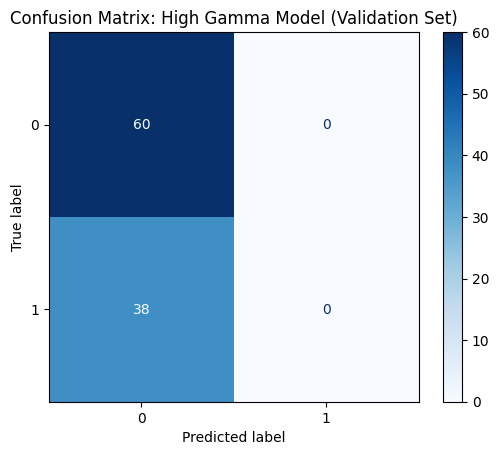


Confusion Matrix for Low Gamma Model (Validation Set):
[[55  5]
 [21 17]]


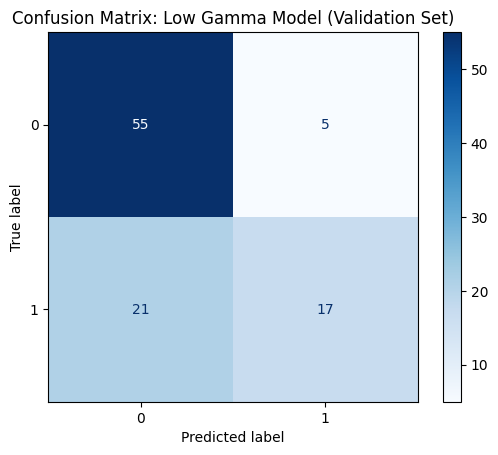

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# matrix high gamma val
cm_high_gamma = confusion_matrix(Y_val, Y_val_pred_high_gamma)
print("Confusion Matrix for High Gamma Model (Validation Set):")
print(cm_high_gamma)

disp_high_gamma = ConfusionMatrixDisplay(confusion_matrix=cm_high_gamma, display_labels=model_high_gamma.classes_)
disp_high_gamma.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix: High Gamma Model (Validation Set)')
plt.show()

# matrix low gamma val
cm_low_gamma = confusion_matrix(Y_val, y_val_pred_low_gamma)
print("\nConfusion Matrix for Low Gamma Model (Validation Set):")
print(cm_low_gamma)

disp_low_gamma = ConfusionMatrixDisplay(confusion_matrix=cm_low_gamma, display_labels=model_low_gamma.classes_)
disp_low_gamma.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix: Low Gamma Model (Validation Set)')
plt.show()